# 1. Question:
How does company size, job title, employment type and experience level impact increasing salary in USD for data science positions?

# 2. Response and Predictor Variables
- **Salary_in_USD** as the repsonse variable y (continuous - numeric)
- Predictor Variables X are: **company size, job title, employment type and experience level**.

# 3. Data Preparation

In [ ]:
# Install Scikit Learn
!pip install -Uqq scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 43.2 MB/s eta 0:00:00


In [ ]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score


In [ ]:
# Load the Salaries Dataset
salaries = pd.read_csv('https://raw.githubusercontent.com/CameronMangione/Group_Project_2_DATA_5322/main/data/ds_salaries_clean.csv'
                       ,index_col=0)

In [ ]:
# data preview
salaries.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
ID,,,,,,,,,,,
1,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
2,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
3,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
4,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
5,2020,EN,FT,Data Scientist,43200,EUR,49268,DE,0,DE,S


In [ ]:
# data types
salaries.dtypes

,0
work_year,int64
experience_level,object
employment_type,object
job_title,object
salary,int64
salary_currency,object
salary_in_usd,int64
employee_residence,object
remote_ratio,int64
company_location,object


Response variable Salary is a continuous (numeric) variable, we will convert it to categorical. We first check the salary ranges, to determine categories.

In [ ]:
# Check Salaries_in_usd variable range
salaries['salary_in_usd'].describe()

,salary_in_usd
count,3191.000000
mean,129393.414917
std,68372.802497
min,2859.000000
25%,80000.000000
50%,124234.000000
75%,170000.000000
max,600000.000000


In [ ]:
# Create 3 categories for salaries - Low, Medium, High
salaries['salary_in_usd'] = pd.cut(salaries['salary_in_usd'],
                                      bins=[0, 90000, 173000, 600000],
                                      labels=['Low', 'Medium', 'High'])

In [ ]:
# verify salary categories
salaries['salary_in_usd'].value_counts()

,count
salary_in_usd,
Medium,1448
Low,977
High,766


In [ ]:
# one-hot encode our 4 categorical variables
encoder = OneHotEncoder(handle_unknown='ignore')
encoded_cols = pd.DataFrame(encoder.fit_transform(salaries[['experience_level', 'employment_type', 'job_title', 'company_size']]).toarray())
encoded_cols.columns = encoder.get_feature_names_out(['experience_level', 'employment_type', 'job_title', 'company_size'])

# Split Train and Test Sets
X = encoded_cols
y = salaries['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                  train_size = 0.5, test_size=0.5,
                                                 random_state=42)

# reset the index of the salaries DataFrame
salaries = salaries.reset_index(drop=True)

In [ ]:
print(X.shape)
print(y.value_counts())

(3191, 106)
salary_in_usd
Medium    1448
Low        977
High       766
Name: count, dtype: int64


# 4. Apply bagging, random forest, and boosting Models


## 4.1 Bagging

In [ ]:
# fit Random Forests model

salaries_bagging = RandomForestClassifier(max_features=X_train.shape[1], random_state=1)
salaries_bagging.fit(X_train, y_train)

print("Number of trees:", salaries_bagging.n_estimators)
print("Number of features tried at each split:", salaries_bagging.max_features)
# For a classifier, .score() returns the mean accuracy
print("Training accuracy: {:.2f}%".format(salaries_bagging.score(X_train, y_train) * 100))


Number of trees: 100
Number of features tried at each split: 106
Training accuracy: 65.33%


In [ ]:
# Test Accuracy
print("Test accuracy: {:.2f}%".format(salaries_bagging.score(X_test, y_test) * 100))

Test accuracy: 55.33%


How well does this bagged model perform on the test set?

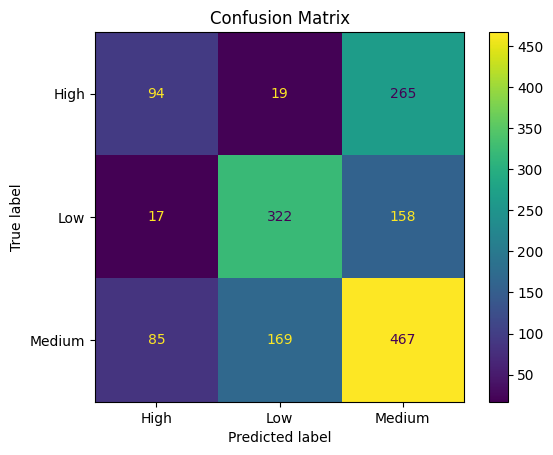

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict values
y_pred_bag = salaries_bagging.predict(X_test)

# plot confusion matrix
cm = confusion_matrix(y_test, y_pred_bag)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=salaries_bagging.classes_)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

Observation:
- The model performs best at predicting medium with medium salary (467), possible because medium has the largest number of values.
- The model struggles with predicting High salary, as High is seen often predicted as Medium (265), this tells us the model may be suffering from class imbalance bias, where the model favors the majority 'Medium', over the minority 'Low' and 'High'.
- Low salaries prediction also struggling, predicted often as Medium (158).

The bagging model performs best on Medium salary classification with 911 correct predictions, but struggles to distinguish High salaries from Medium, misclassifying 265 High salaries as Medium. This suggests the model is biased toward the majority class.

In [ ]:
# find the accuracy
from sklearn.metrics import accuracy_score
print("Accuracy Score: {:.2f}%".format(accuracy_score(y_test, y_pred_bag) * 100))

Accuracy Score: 55.33%


this confirms our test score earlier.

The test accuracy score associated with the bagged regression tree is 56.95%, which suggests that the model has some level of prediction error, but it is still performing reasonably well. We could change the number of trees grown by the `RandomForestClassification()` using the `n_estimators` parameter. By default, `n_estimators` is set to 100.

## 4.2 Random Forest

Training accuracy: 65.33%
Test accuracy: 55.26%


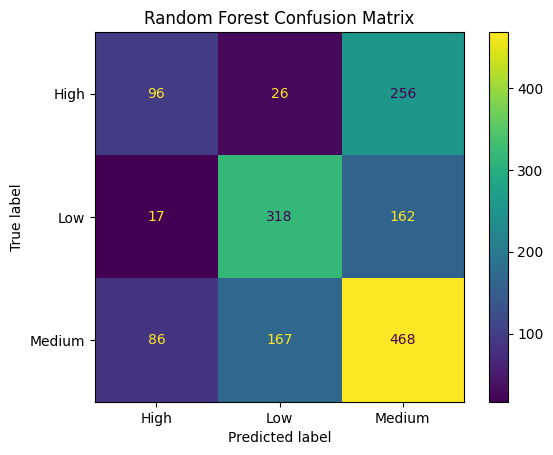

In [ ]:
# fit Random Forest model
salaries_rf = RandomForestClassifier(max_features='sqrt', random_state=1)
salaries_rf.fit(X_train, y_train)

# accuracy
y_pred_rf = salaries_rf.predict(X_test)
print("Training accuracy: {:.2f}%".format(salaries_rf.score(X_train, y_train) * 100))
print("Test accuracy: {:.2f}%".format(salaries_rf.score(X_test, y_test) * 100))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=salaries_rf.classes_)
disp.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

The test accuracy is 55.26%; this indicates that random forests yielded an improvement over bagging in this case.

## 4.3 Boosting

In [ ]:
# fit Gradient Boosting classifier model for salaries
boost_salaries = GradientBoostingClassifier(
                  n_estimators=500,
                  max_depth=4 ,
                  random_state=1,
                  learning_rate=0.1)
boost_salaries.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [ ]:
print("Training accuracy: {:.2f}%".format(boost_salaries.score(X_train, y_train) * 100))
print("Test accuracy: {:.2f}%".format(boost_salaries.score(X_test, y_test) * 100))

Training accuracy: 65.14%
Test accuracy: 56.64%


All three models are performing very similarly around 57% test accuracy. This suggests the problem itself is challenging, salary categories are hard to predict perfectly from just these 4 features.
Also we notice all models show a gap between training and test accuracy, which is a sign of some overfitting.

Lets look at the relative influence statistics.

In [ ]:
# create a dataframe of feature importances and their corresponding column names
importances_boost_salaries = pd.DataFrame({'Feature': X_train.columns, 'Importance': boost_salaries.feature_importances_})
importances_boost_salaries = importances_boost_salaries.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_boost_salaries)

                                           Feature  Importance
0                              experience_level_SE    0.303900
1                              experience_level_EX    0.078583
2                                   company_size_M    0.063528
3                           job_title_Data Analyst    0.047922
4                              experience_level_EN    0.044798
..                                             ...         ...
101              job_title_Marketing Data Engineer    0.000000
102               job_title_Product Data Scientist    0.000000
103  job_title_Principal Machine Learning Engineer    0.000000
104                   job_title_Power BI Developer    0.000000
105                   job_title_Staff Data Analyst    0.000000

[106 rows x 2 columns]


We see that `experience_level_SE`(Senior) and `experience_level_EX`(Executive) are by far the most important variables. We can also produce partial dependence plots for these two variables using `PartialDependenceDisplay.from_estimator` method from `scikit-learn` `inspection` module. These plots illustrate the marginal effect of the selected variables on the response after integrating out the other variables.

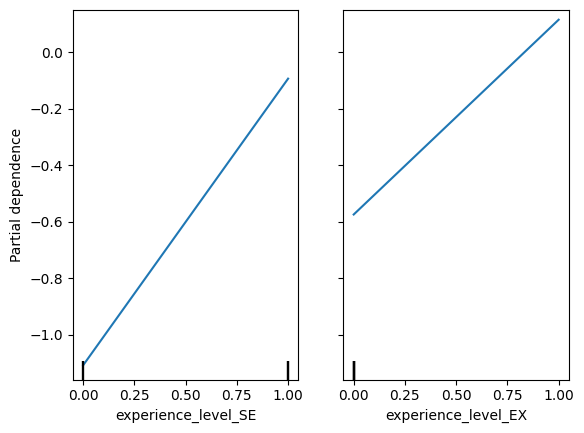

In [ ]:
PartialDependenceDisplay.from_estimator(
    boost_salaries, X_train,
     ['experience_level_SE', 'experience_level_EX'], target='High');

This confirms that a growth in both features is directly proportional to the growth in salaries in usd.

# 5. New Boosting Method: XGBoost

In [ ]:
!pip install xgboost
from xgboost import XGBClassifier

In [ ]:
# Convert predictor categories to numeric
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(le.classes_)

['High' 'Low' 'Medium']


In [ ]:
# fit the model
salaries_xgb = XGBClassifier(n_estimators=500,
                             max_depth=4,
                             learning_rate=0.1,
                             random_state=1)

salaries_xgb.fit(X_train, y_train_encoded)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [ ]:
# Evaluate
print("Training accuracy: {:.2f}%".format(salaries_xgb.score(X_train, y_train_encoded) * 100))
print("Test accuracy: {:.2f}%".format(salaries_xgb.score(X_test, y_test_encoded) * 100))

Training accuracy: 62.13%
Test accuracy: 55.64%


Model Comparison: All models are still clustering around 56-57% test accuracy.
Random Forest is technically the best performer on test data, while XGBoost has the lowest training accuracy suggesting it generalizes slightly better (less overfitting).

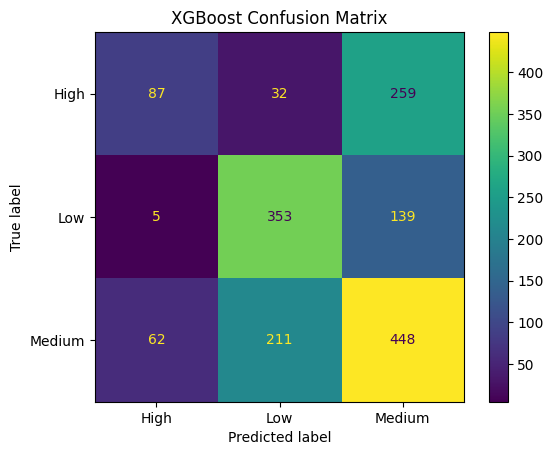

In [ ]:
# XGBoost Confusion Matrix
y_pred_xgb = salaries_xgb.predict(X_test)

cm = confusion_matrix(y_test_encoded, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=le.classes_)

disp.plot()
plt.title('XGBoost Confusion Matrix')
plt.show()


In [ ]:
# feature importance
importances_xgb = pd.DataFrame({'Feature': X_train.columns,
                                  'Importance': salaries_xgb.feature_importances_})
importances_xgb = importances_xgb.sort_values('Importance', ascending=False).reset_index(drop=True)
print(importances_xgb.head(10))

                            Feature  Importance
0               experience_level_SE    0.135605
1               experience_level_EX    0.088952
2            job_title_Data Analyst    0.080733
3  job_title_Data Analytics Manager    0.049520
4           job_title_ETL Developer    0.037169
5            job_title_BI Developer    0.032907
6                    company_size_M    0.028996
7           job_title_Data Engineer    0.027457
8       job_title_Applied Scientist    0.023383
9      job_title_Research Scientist    0.022603


Key observation: models agree that experience_level and job_title are the most important features, but they disagree on the order, GBM puts experience first while XGBoost puts job title first.

# 6. Support Vector Classifier Method

Import SVC libraries

In [ ]:
import numpy as np
from matplotlib.pyplot import subplots, cm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table

from sklearn.svm import SVC
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay

scale features for kernel processing

In [ ]:
# scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Fit SVC Model, starting with an RBF kernel, best fit for our non-linear problem

In [ ]:
# fit svc model with an rbf
salaries_svc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=1)
salaries_svc.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
# view the features we have in our training set
print(X_train.columns)

Index(['experience_level_EN', 'experience_level_EX', 'experience_level_MI',
       'experience_level_SE', 'employment_type_CT', 'employment_type_FL',
       'employment_type_FT', 'employment_type_PT',
       'job_title_3D Computer Vision Researcher', 'job_title_AI Developer',
       ...
       'job_title_Product Data Analyst', 'job_title_Product Data Scientist',
       'job_title_Research Engineer', 'job_title_Research Scientist',
       'job_title_Software Data Engineer', 'job_title_Staff Data Analyst',
       'job_title_Staff Data Scientist', 'company_size_L', 'company_size_M',
       'company_size_S'],
      dtype='object', length=106)


106 features within our training set. SVM requires 2 to 3 features for visualizations, since this project has hundreds of OneHot-encoded features, features, making direct hyperplane plot will be impossible to do for interpretation. We will try two options:
1. Reduce to 2D with PCA: we compress our hundreds of features down to 2 principal components, then plot the decision boundary in that reduced space
2. Select 2 specific features manually and fit SVM: we will choose the top two most important features from our feature importance analysis

## PCA Reduction to 2D

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


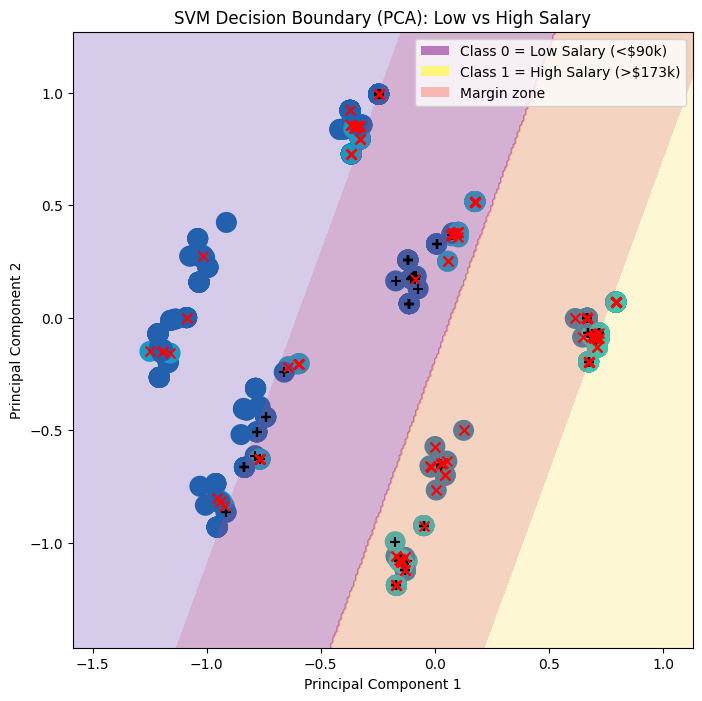

Variance explained by PC1 and PC2: 37.16%


In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

from sklearn.decomposition import PCA
from matplotlib.patches import Patch

# binary labels
mask = salaries['salary_in_usd'] != 'Medium'
y_binary = salaries['salary_in_usd'][mask].map({'Low': 0, 'High': 1})

# align X with the mask
X_masked = X[mask].reset_index(drop=True)
y_binary = y_binary.reset_index(drop=True)

# train/test split first, then PCA
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_masked, y_binary, train_size=0.5, random_state=42)

# PCA
pca = PCA(n_components=2)
X_train_2d = pd.DataFrame(pca.fit_transform(X_train_m), columns=['PC1', 'PC2'])
X_test_2d  = pd.DataFrame(pca.transform(X_test_m),      columns=['PC1', 'PC2'])

y_train_m = y_train_m.reset_index(drop=True)

# fit SVM
svc_pca = SVC(C=100, kernel='linear')
svc_pca.fit(X_train_2d, y_train_m)

# plot
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train_2d, y_train_m, svc_pca, ax=ax)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('SVM Decision Boundary (PCA): Low vs High Salary')

ax.legend(handles=[
    Patch(facecolor='purple', alpha=0.5, label='Class 0 = Low Salary (<$90k)'),
    Patch(facecolor='yellow', alpha=0.5, label='Class 1 = High Salary (>$173k)'),
    Patch(facecolor='salmon', alpha=0.5, label='Margin zone')
])
plt.show()

# variance check
print("Variance explained by PC1 and PC2: {:.2f}%".format(
      sum(pca.explained_variance_ratio_) * 100))

The PCA visualization captures 37.16% of the total variance in the data.
While the decision boundary is visually interpretable, it represents a
compressed approximation, 62.84% of the feature information is not
reflected in this 2D plot.

## Feature Selection

In [ ]:
# Top 2 features selected
feature1 = 'experience_level_SE'
feature2 = 'experience_level_EX'

X_train_2feat = X_train_scaled[:, [X_train.columns.get_loc(feature1),
                                    X_train.columns.get_loc(feature2)]]
X_test_2feat  = X_test_scaled[:,  [X_train.columns.get_loc(feature1),
                                    X_train.columns.get_loc(feature2)]]

# Fit and plot
svc_2feat = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=1)
svc_2feat.fit(X_train_2feat, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
!pip install ISLP

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


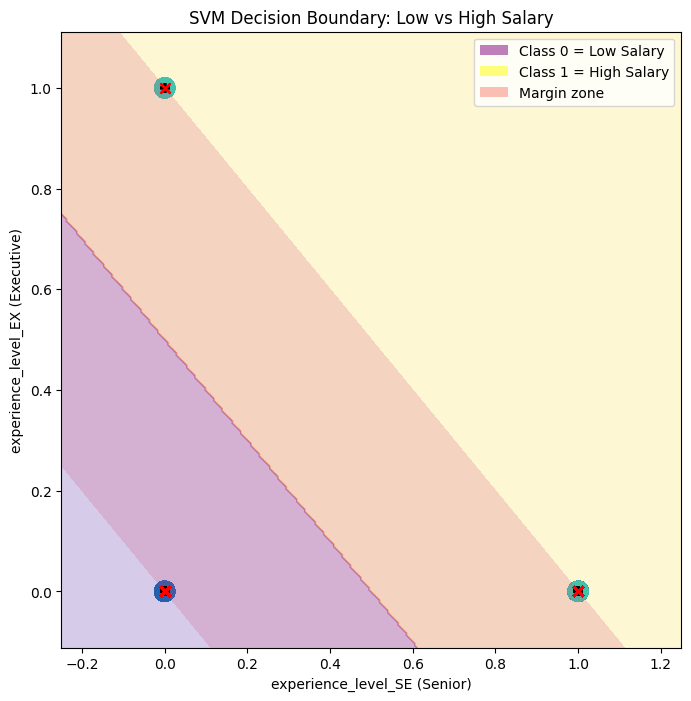

In [ ]:
from ISLP.svm import plot as plot_svm
from matplotlib.patches import Patch

# binary labels
mask = salaries['salary_in_usd'] != 'Medium'
y_binary = salaries['salary_in_usd'][mask].map({'Low': 0, 'High': 1})

# select 2 important features
X_binary = X[mask][['experience_level_SE', 'experience_level_EX']]
X_binary = X_binary.reset_index(drop=True)
y_binary = y_binary.reset_index(drop=True)

# train/test split
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary, y_binary, train_size=0.5, random_state=42)

X_train_bin = X_train_bin.reset_index(drop=True)
y_train_bin = y_train_bin.reset_index(drop=True)

# fit linear SVM
svc_binary = SVC(C=0.1, kernel='linear')
svc_binary.fit(X_train_bin, y_train_bin)

# plot
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train_bin, y_train_bin, svc_binary, ax=ax)

ax.set_xlabel('experience_level_SE (Senior)')
ax.set_ylabel('experience_level_EX (Executive)')
ax.set_title('SVM Decision Boundary: Low vs High Salary')

ax.legend(handles=[
    Patch(facecolor='purple', alpha=0.5, label='Class 0 = Low Salary'),
    Patch(facecolor='yellow', alpha=0.5, label='Class 1 = High Salary'),
    Patch(facecolor='salmon', alpha=0.5, label='Margin zone')
])
plt.show()

The SVM decision boundary plot shows that Senior (SE) and Executive (EX) experience levels have a meaningful but limited influence on predicting salary class. Points at (1,0) Senior but not Executive lean toward the High salary (>173k) zone, while points at (0,0) neither qualification lean toward the Low salary (<$90k) zone. However, all points fall within or near the margin band, and every point is a support vector, meaning the model struggles to confidently separate the two salary classes using these two features alone. This suggests that while Senior and Executive experience level do influence salary, they are not sufficient on their own to clearly determine whether someone earns a Low or High salary, other features in the dataset are likely contributing to the prediction as well.

We will adjust to a smaller c value to allow for more generalization

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


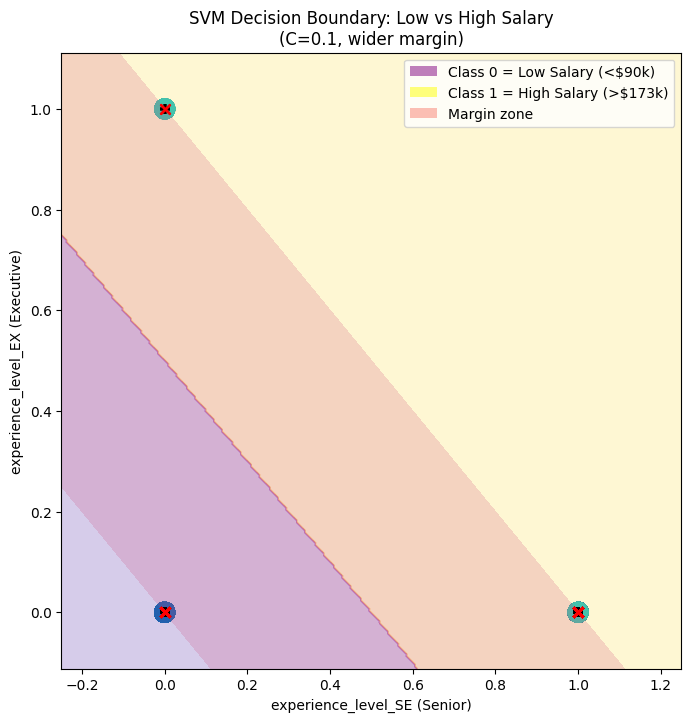

In [ ]:
# smaller C value = wider margin, more generalization
svc_binary = SVC(C=0.1, kernel='linear')
svc_binary.fit(X_train_bin, y_train_bin)

# plot
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train_bin, y_train_bin, svc_binary, ax=ax)

ax.set_xlabel('experience_level_SE (Senior)')
ax.set_ylabel('experience_level_EX (Executive)')
ax.set_title('SVM Decision Boundary: Low vs High Salary\n(C=0.1, wider margin)')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='purple', alpha=0.5, label='Class 0 = Low Salary (<$90k)'),
    Patch(facecolor='yellow', alpha=0.5, label='Class 1 = High Salary (>$173k)'),
    Patch(facecolor='salmon', alpha=0.5, label='Margin zone')
])
plt.show()

Since our data only has 4 coordinate positions, the plot looks virtually identical, the margin band is slightly wider but nothing meaningful changed visually. we can extract the coefficients of the linear decision boundary

In [ ]:
svc_binary.coef_

array([[2., 2.]])

# 7. Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(SVC(random_state=1),
                           param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1)
grid_search.fit(X_train_bin, y_train_bin)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy: {:.2f}%".format(grid_search.best_score_ * 100))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV accuracy: 79.33%


Best C = 0.1. the model prefers a wide margin with more tolerance for misclassifications, Kernal confirms our data is linearly separable between Low and High salary.

# 8. Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score

svc_tuned = SVC(C=0.1, kernel='linear', gamma='scale', random_state=1)

cv_scores = cross_val_score(svc_tuned, X_train_bin, y_train_bin, cv=5, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy: {:.2f}%".format(cv_scores.mean() * 100))
print("Standard deviation: {:.2f}%".format(cv_scores.std() * 100))

Cross-validation scores: [0.79428571 0.79885057 0.78735632 0.83908046 0.74712644]
Mean CV accuracy: 79.33%
Standard deviation: 2.93%


The 5-fold cross validation confirms the tuned SVC (C=0.1, linear kernel)
is stable with a mean accuracy of 79.33% and low variance of 2.93% across
folds, indicating the model generalizes consistently to unseen data.

### Replotting with Tuned Parameters

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


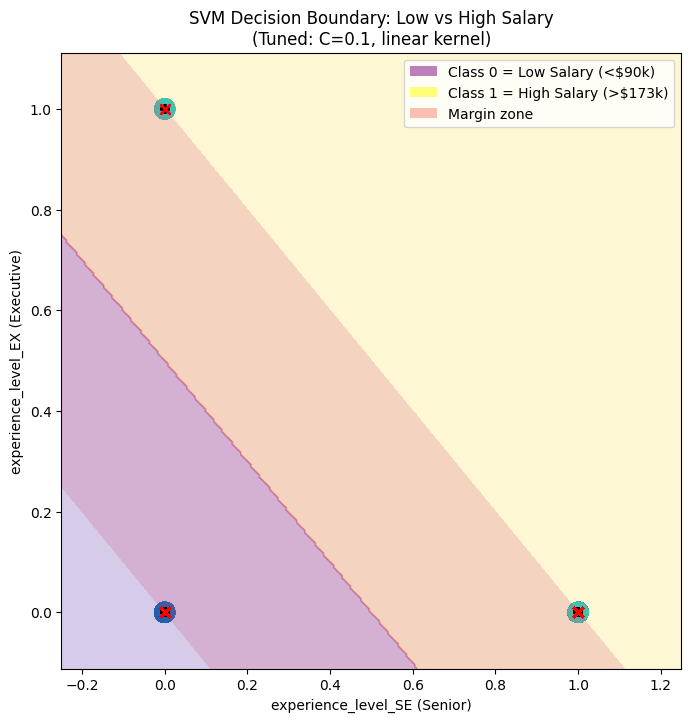

In [ ]:
svc_tuned = SVC(C=0.1, kernel='linear', gamma='scale', random_state=1)
svc_tuned.fit(X_train_bin, y_train_bin)

fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train_bin, y_train_bin, svc_tuned, ax=ax)

ax.set_xlabel('experience_level_SE (Senior)')
ax.set_ylabel('experience_level_EX (Executive)')
ax.set_title('SVM Decision Boundary: Low vs High Salary\n(Tuned: C=0.1, linear kernel)')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='purple', alpha=0.5, label='Class 0 = Low Salary (<$90k)'),
    Patch(facecolor='yellow', alpha=0.5, label='Class 1 = High Salary (>$173k)'),
    Patch(facecolor='salmon', alpha=0.5, label='Margin zone')
])
plt.show()

The plot looks identical to the previous one, since tuning confirmed C=0.1 and linear kernel were already the optimal parameters, nothing changed visually.

# 7. Model Comparison

Performance

In [ ]:
from sklearn.metrics import accuracy_score

# 2-feature binary SVC (tuned)
y_pred_svc_2feat = svc_tuned.predict(X_test_bin)
acc_svc_2feat = accuracy_score(y_test_bin, y_pred_svc_2feat) * 100

# PCA binary SVC
y_pred_svc_pca = svc_pca.predict(X_test_2d)
acc_svc_pca = accuracy_score(y_test_m, y_pred_svc_pca) * 100

# previous tree-based models (3-class)
y_pred_bag  = salaries_bagging.predict(X_test)
y_pred_rf   = salaries_rf.predict(X_test)
y_pred_boost = boost_salaries.predict(X_test)
y_pred_xgb  = salaries_xgb.predict(X_test)

acc_bag   = accuracy_score(y_test, y_pred_bag)   * 100
acc_rf    = accuracy_score(y_test, y_pred_rf)    * 100
acc_boost = accuracy_score(y_test, y_pred_boost) * 100
acc_xgb   = accuracy_score(y_test, le.inverse_transform(y_pred_xgb)) * 100

# comparison table
print("=" * 55)
print("{:<35} {:>10}".format("Model", "Test Accuracy"))
print("=" * 55)
print("{:<35} {:>10}".format("Bagging (3-class)",         "{:>.2f}%".format(acc_bag)))
print("{:<35} {:>10}".format("Random Forest (3-class)",   "{:>.2f}%".format(acc_rf)))
print("{:<35} {:>10}".format("Boosting (3-class)",        "{:>.2f}%".format(acc_boost)))
print("{:<35} {:>10}".format("XGBoost (3-class)",         "{:>.2f}%".format(acc_xgb)))
print("-" * 55)
print("{:<35} {:>10}".format("SVC 2-feature (binary)",    "{:>.2f}%".format(acc_svc_2feat)))
print("{:<35} {:>10}".format("SVC PCA (binary)",          "{:>.2f}%".format(acc_svc_pca)))
print("=" * 55)
print()


Model                               Test Accuracy
Bagging (3-class)                       55.33%
Random Forest (3-class)                 55.26%
Boosting (3-class)                      56.64%
XGBoost (3-class)                       55.64%
-------------------------------------------------------
SVC 2-feature (binary)                  79.82%
SVC PCA (binary)                        77.18%



# 7. Comparison with tree-based method

The tree-based models (Bagging, Random Forest, Boosting, and XGBoost) all performed similarly, clustering between 55% and 57% test accuracy on the three-class problem (Low, Medium, High). The SVC models achieved notably higher accuracies of 79.82% and 77.18% respectively, however this comparison is not directly equivalent based on the nature of our data. The SVC models were trained on a simpler binary classification task (Low vs High only), with the Medium salary class removed entirely. A fairer interpretation is that the SVC confirms strong separability between the two salary extremes, while the tree-based models tackled the harder and more realistic three-class problem where distinguishing Medium salaries from Low and High proved genuinely challenging.